# GARCH VaR/ES Benchmark Backtesting

This notebook builds econometric benchmark models for MASI tail-risk forecasting. It uses a strict chronological rolling-window protocol, screens EGARCH and GJR-GARCH specifications, produces one-step-ahead VaR/ES forecasts, and evaluates both statistical backtests and economic allocation metrics.

## Notebook flow

1. Load the MASI master dataset.
2. Prepare the fixed rolling-window benchmark split.
3. Fit and screen EGARCH and GJR-GARCH candidates.
4. Forecast VaR and ES on the out-of-sample test period.
5. Run risk backtests and economic strategy evaluation.


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/processed/final/master_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df.head()


## Chronological Rolling Split

The benchmark uses a fixed-size rolling estimation window to avoid look-ahead bias and keep every forecast strictly one-step-ahead.


In [3]:
from src.analysis.garch_benchmark_utils import prepare_rolling_var_benchmark_split


In [4]:
rolling_protocol = prepare_rolling_var_benchmark_split(df)

train_initial_df = rolling_protocol.train_initial_df
test_df = rolling_protocol.test_df
rolling_windows_info = rolling_protocol.rolling_windows_info


Rolling VaR benchmark split prepared
Check total observations:          4000 + 764 = 4764
Total observations in dataset:     4764
Initial estimation sample size:    4000
Backtesting sample size:           764
Initial train index range:         0 to 3999
Test index range:                  4000 to 4763
Expected out-of-sample forecasts:  764

First rolling window
  Train indices:                   0 to 3999
  Train dates:                     2007-01-31 00:00:00 to 2023-02-15 00:00:00
  Forecast index:                  4000
  Forecast date:                   2023-02-16 00:00:00

Last rolling window
  Train indices:                   763 to 4762
  Train dates:                     2010-03-01 00:00:00 to 2026-03-18 00:00:00
  Forecast index:                  4763
  Forecast date:                   2026-03-19 00:00:00


## Econometric Model Fitting

The reusable fitting functions live in `src.analysis.garch_benchmark_utils`; the notebook cells below keep the model screening and displayed outputs visible.


e garch

In [5]:
from src.analysis.garch_benchmark_utils import fit_forecast_egarch


gjr garch

In [6]:
from src.analysis.garch_benchmark_utils import fit_forecast_gjr_garch


## Parametric VaR and Expected Shortfall

The next cell imports the parametric VaR/ES implementation and runs deterministic self-tests before the benchmark forecasts use it.


In [7]:
from src.analysis.garch_benchmark_utils import (
    compute_parametric_var_es,
    run_parametric_var_es_self_tests,
)

run_parametric_var_es_self_tests(verbose=True)


Self-tests passed.

normal_5pct              VaR=-0.01644854   ES=-0.02062713
student_t_df8_5pct       VaR=-0.01610416   ES=-0.02177060
ged_beta_1_5_5pct        VaR=-0.01652739   ES=-0.02173011
zero_volatility          VaR= 0.00100000   ES= 0.00100000
negative_mean_forecast   VaR=-0.01744854   ES=-0.02162713


[('normal_5pct',
  np.float64(-0.01644853626951473),
  np.float64(-0.020627128075074254)),
 ('student_t_df8_5pct',
  np.float64(-0.016104158400592563),
  np.float64(-0.021770604941459104)),
 ('ged_beta_1_5_5pct', np.float64(-0.01652739105514966), -0.02173011050322565),
 ('zero_volatility', 0.001, 0.001),
 ('negative_mean_forecast',
  np.float64(-0.01744853626951473),
  np.float64(-0.021627128075074255))]

## Candidate Screening

The following result cells compare candidate specifications using log-likelihood, AIC, and BIC on the initial training window.


In [8]:
import numpy as np
import pandas as pd

# Initial estimation sample only:
# use the first fixed rolling window, not the old expanding-window slice
RETURN_COLUMN = "masi_log_return"
initial_training_returns = pd.to_numeric(
    train_initial_df[RETURN_COLUMN],
    errors="coerce",
).dropna()

if initial_training_returns.empty:
    raise ValueError("Initial training sample is empty after numeric conversion.")

candidate_model_families = ["EGARCH", "GJR-GARCH"]
candidate_mean_specs = ["zero", "constant", "ar1"]
candidate_innovation_dists = ["normal", "t", "ged"]

# Explicit model orders, with no hidden assumptions
egarch_candidate_orders = [(1, 1, 1), (1, 1, 2), (2, 1, 1), (2, 1, 2)]
gjr_garch_candidate_orders = [(1, 1, 1), (1, 1, 2), (2, 1, 1), (2, 1, 2)]

screening_rows = []

for model_family in candidate_model_families:
    candidate_orders = (
        egarch_candidate_orders if model_family == "EGARCH" else gjr_garch_candidate_orders
    )

    for mean_spec in candidate_mean_specs:
        for innovation_dist in candidate_innovation_dists:
            for p, o, q in candidate_orders:
                if model_family == "EGARCH":
                    fit_output = fit_forecast_egarch(
                        training_returns=initial_training_returns,
                        mean_spec=mean_spec,
                        innovation_dist=innovation_dist,
                        p=p,
                        o=o,
                        q=q,
                    )
                else:
                    fit_output = fit_forecast_gjr_garch(
                        training_returns=initial_training_returns,
                        mean_spec=mean_spec,
                        innovation_dist=innovation_dist,
                        p=p,
                        o=o,
                        q=q,
                    )

                fitted_model_result = fit_output["fitted_result"]

                screening_rows.append(
                    {
                        "model_family": model_family,
                        "mean_spec": mean_spec,
                        "innovation_dist": innovation_dist,
                        "model_orders": (p, o, q),
                        "fit_success": fit_output["success"],
                        "error_message": fit_output["error"],
                        "loglikelihood": (
                            fitted_model_result.loglikelihood
                            if fitted_model_result is not None
                            else np.nan
                        ),
                        "aic": (
                            fitted_model_result.aic
                            if fitted_model_result is not None
                            else np.nan
                        ),
                        "bic": (
                            fitted_model_result.bic
                            if fitted_model_result is not None
                            else np.nan
                        ),
                    }
                )

screening_results = pd.DataFrame(screening_rows)

print(f"screening_results shape: {screening_results.shape}")
print(screening_results.head())


screening_results shape: (72, 9)
  model_family mean_spec innovation_dist model_orders  fit_success  \
0       EGARCH      zero          normal    (1, 1, 1)         True   
1       EGARCH      zero          normal    (1, 1, 2)         True   
2       EGARCH      zero          normal    (2, 1, 1)         True   
3       EGARCH      zero          normal    (2, 1, 2)         True   
4       EGARCH      zero               t    (1, 1, 1)         True   

  error_message  loglikelihood          aic          bic  
0          None   -3873.279985  7754.559970  7779.736168  
1          None   -3867.186618  7744.373236  7775.843484  
2          None   -3862.422665  7734.845329  7766.315578  
3          None   -3862.422665  7736.845329  7774.609627  
4          None   -3692.102053  7394.204106  7425.674354  


In [9]:
screening_results_valid = screening_results[
    screening_results["fit_success"]
    & screening_results["loglikelihood"].notna()
    & screening_results["bic"].notna()
    & screening_results["aic"].notna()
    & np.isfinite(screening_results["loglikelihood"])
    & np.isfinite(screening_results["bic"])
    & np.isfinite(screening_results["aic"])
].copy()

best_in_sample_by_family = (
    screening_results_valid
    .sort_values(["model_family", "bic", "aic", "loglikelihood"], ascending=[True, True, True, False])
    .groupby("model_family", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print(best_in_sample_by_family)

print("\nSummary of best in-sample models by family:")
for _, row in best_in_sample_by_family.iterrows():
    print(
        f"{row['model_family']:<10} | "
        f"Mean Spec: {row['mean_spec']:<8} | "
        f"Innovation Dist: {row['innovation_dist']:<6} | "
        f"Orders (p,o,q): {row['model_orders']} | "
        f"LogLik: {row['loglikelihood']:.2f} | "
        f"BIC: {row['bic']:.2f} | "
        f"AIC: {row['aic']:.2f}"
    )


  model_family mean_spec innovation_dist model_orders  fit_success  \
0       EGARCH       ar1               t    (2, 1, 1)         True   
1    GJR-GARCH       ar1               t    (1, 1, 1)         True   

  error_message  loglikelihood          aic          bic  
0          None   -3662.981520  7341.963041  7392.313438  
1          None   -3662.721634  7339.443268  7383.499865  

Summary of best in-sample models by family:
EGARCH     | Mean Spec: ar1      | Innovation Dist: t      | Orders (p,o,q): (2, 1, 1) | LogLik: -3662.98 | BIC: 7392.31 | AIC: 7341.96
GJR-GARCH  | Mean Spec: ar1      | Innovation Dist: t      | Orders (p,o,q): (1, 1, 1) | LogLik: -3662.72 | BIC: 7383.50 | AIC: 7339.44


In [10]:
# Refit and display the full summaries of the two retained in-sample specifications
# using the initial fixed rolling training window

initial_training_returns = pd.to_numeric(
    train_initial_df[RETURN_COLUMN],
    errors="coerce",
).dropna()

if initial_training_returns.empty:
    raise ValueError("Initial training sample is empty after numeric conversion.")

egarch_selected = fit_forecast_egarch(
    training_returns=initial_training_returns,
    mean_spec="ar1",
    innovation_dist="t",
    p=2,
    o=1,
    q=1,
)

gjr_garch_selected = fit_forecast_gjr_garch(
    training_returns=initial_training_returns,
    mean_spec="ar1",
    innovation_dist="t",
    p=1,
    o=1,
    q=1,
)

if not egarch_selected["success"]:
    raise ValueError(f"EGARCH refit failed: {egarch_selected['error']}")

if not gjr_garch_selected["success"]:
    raise ValueError(f"GJR-GARCH refit failed: {gjr_garch_selected['error']}")

print("EGARCH summary")
print(egarch_selected["fitted_result"].summary())

print("\nGJR-GARCH summary")
print(gjr_garch_selected["fitted_result"].summary())


EGARCH summary
                             AR - EGARCH Model Results                              
Dep. Variable:              masi_log_return   R-squared:                       0.032
Mean Model:                              AR   Adj. R-squared:                  0.032
Vol Model:                           EGARCH   Log-Likelihood:               -3662.98
Distribution:      Standardized Student's t   AIC:                           7341.96
Method:                  Maximum Likelihood   BIC:                           7392.31
                                              No. Observations:                 3999
Date:                      Sat, Apr 25 2026   Df Residuals:                     3997
Time:                              16:56:05   Df Model:                            2
                                   Mean Model                                  
                    coef    std err          t      P>|t|      95.0% Conf. Int.
------------------------------------------------------------

## Rolling Forecasting

The retained specifications are refit through the rolling protocol to produce out-of-sample VaR and ES forecasts.


In [11]:
import numpy as np
import pandas as pd

retained_specifications = [
    {
        "model_family": "EGARCH",
        "mean_spec": "ar1",
        "innovation_dist": "t",
        "model_orders": (2, 1, 1),
    },
    {
        "model_family": "GJR-GARCH",
        "mean_spec": "ar1",
        "innovation_dist": "t",
        "model_orders": (1, 1, 1),
    },
]

forecast_rows = []

for _, window_row in rolling_windows_info.iterrows():
    train_start_index = int(window_row["train_start_index"])
    train_end_index = int(window_row["train_end_index"])
    forecast_index = int(window_row["forecast_index"])

    training_returns = pd.to_numeric(
        df.loc[train_start_index:train_end_index, RETURN_COLUMN],
        errors="coerce",
    ).dropna()

    if training_returns.empty:
        raise ValueError(
            f"Training window is empty after numeric conversion for "
            f"forecast_index={forecast_index}."
        )

    forecast_date = df.loc[forecast_index, "date"]
    realized_return = float(df.loc[forecast_index, RETURN_COLUMN])

    for specification in retained_specifications:
        model_family = specification["model_family"]
        mean_spec = specification["mean_spec"]
        innovation_dist = specification["innovation_dist"]
        p, o, q = specification["model_orders"]

        # Daily refit on the current fixed rolling window
        if model_family == "EGARCH":
            fit_output = fit_forecast_egarch(
                training_returns=training_returns,
                mean_spec=mean_spec,
                innovation_dist=innovation_dist,
                p=p,
                o=o,
                q=q,
            )
        else:
            fit_output = fit_forecast_gjr_garch(
                training_returns=training_returns,
                mean_spec=mean_spec,
                innovation_dist=innovation_dist,
                p=p,
                o=o,
                q=q,
            )

        if not fit_output["success"]:
            raise RuntimeError(
                f"Model fit failed | "
                f"model={model_family} | "
                f"forecast_index={forecast_index} | "
                f"forecast_date={forecast_date} | "
                f"train_window=({train_start_index}, {train_end_index}) | "
                f"orders={(p, o, q)} | "
                f"error={fit_output['error']}"
            )

        fitted_result = fit_output["fitted_result"]
        mean_forecast = float(fit_output["mean_forecast"])
        volatility_forecast = float(fit_output["volatility_forecast"])

        try:
            distribution_parameters = {}
            if innovation_dist == "t":
                distribution_parameters["degrees_of_freedom"] = float(fitted_result.params["nu"])
            elif innovation_dist == "ged":
                distribution_parameters["ged_shape"] = float(fitted_result.params["nu"])

            var_5pct, es_5pct = compute_parametric_var_es(
                mean_forecast=mean_forecast,
                volatility_forecast=volatility_forecast,
                distribution_name=innovation_dist,
                distribution_parameters=distribution_parameters,
                alpha=0.05,
            )

        except Exception as forecast_error:
            raise RuntimeError(
                f"Risk computation failed | "
                f"model={model_family} | "
                f"forecast_index={forecast_index} | "
                f"forecast_date={forecast_date} | "
                f"train_window=({train_start_index}, {train_end_index}) | "
                f"orders={(p, o, q)} | "
                f"mean_forecast={mean_forecast} | "
                f"volatility_forecast={volatility_forecast} | "
                f"error={forecast_error}"
            )

        forecast_rows.append(
            {
                "forecast_date": forecast_date,
                "forecast_index": forecast_index,
                "train_start_index": train_start_index,
                "train_end_index": train_end_index,
                "model_family": model_family,
                "mean_spec": mean_spec,
                "innovation_dist": innovation_dist,
                "model_orders": specification["model_orders"],
                "mean_forecast": mean_forecast,
                "volatility_forecast": volatility_forecast,
                "var_5pct": var_5pct,
                "es_5pct": es_5pct,
                "realized_return": realized_return,
                "error_message": None,
            }
        )

forecast_results = pd.DataFrame(forecast_rows)

print(f"forecast_results shape: {forecast_results.shape}")
print(forecast_results.head())


forecast_results shape: (1528, 14)
  forecast_date  forecast_index  train_start_index  train_end_index  \
0    2023-02-16            4000                  0             3999   
1    2023-02-16            4000                  0             3999   
2    2023-02-17            4001                  1             4000   
3    2023-02-17            4001                  1             4000   
4    2023-02-20            4002                  2             4001   

  model_family mean_spec innovation_dist model_orders  mean_forecast  \
0       EGARCH       ar1               t    (2, 1, 1)       0.000412   
1    GJR-GARCH       ar1               t    (1, 1, 1)       0.000424   
2       EGARCH       ar1               t    (2, 1, 1)       0.000269   
3    GJR-GARCH       ar1               t    (1, 1, 1)       0.000272   
4       EGARCH       ar1               t    (2, 1, 1)       0.001193   

   volatility_forecast  var_5pct   es_5pct  realized_return error_message  
0             0.008468 -0.012

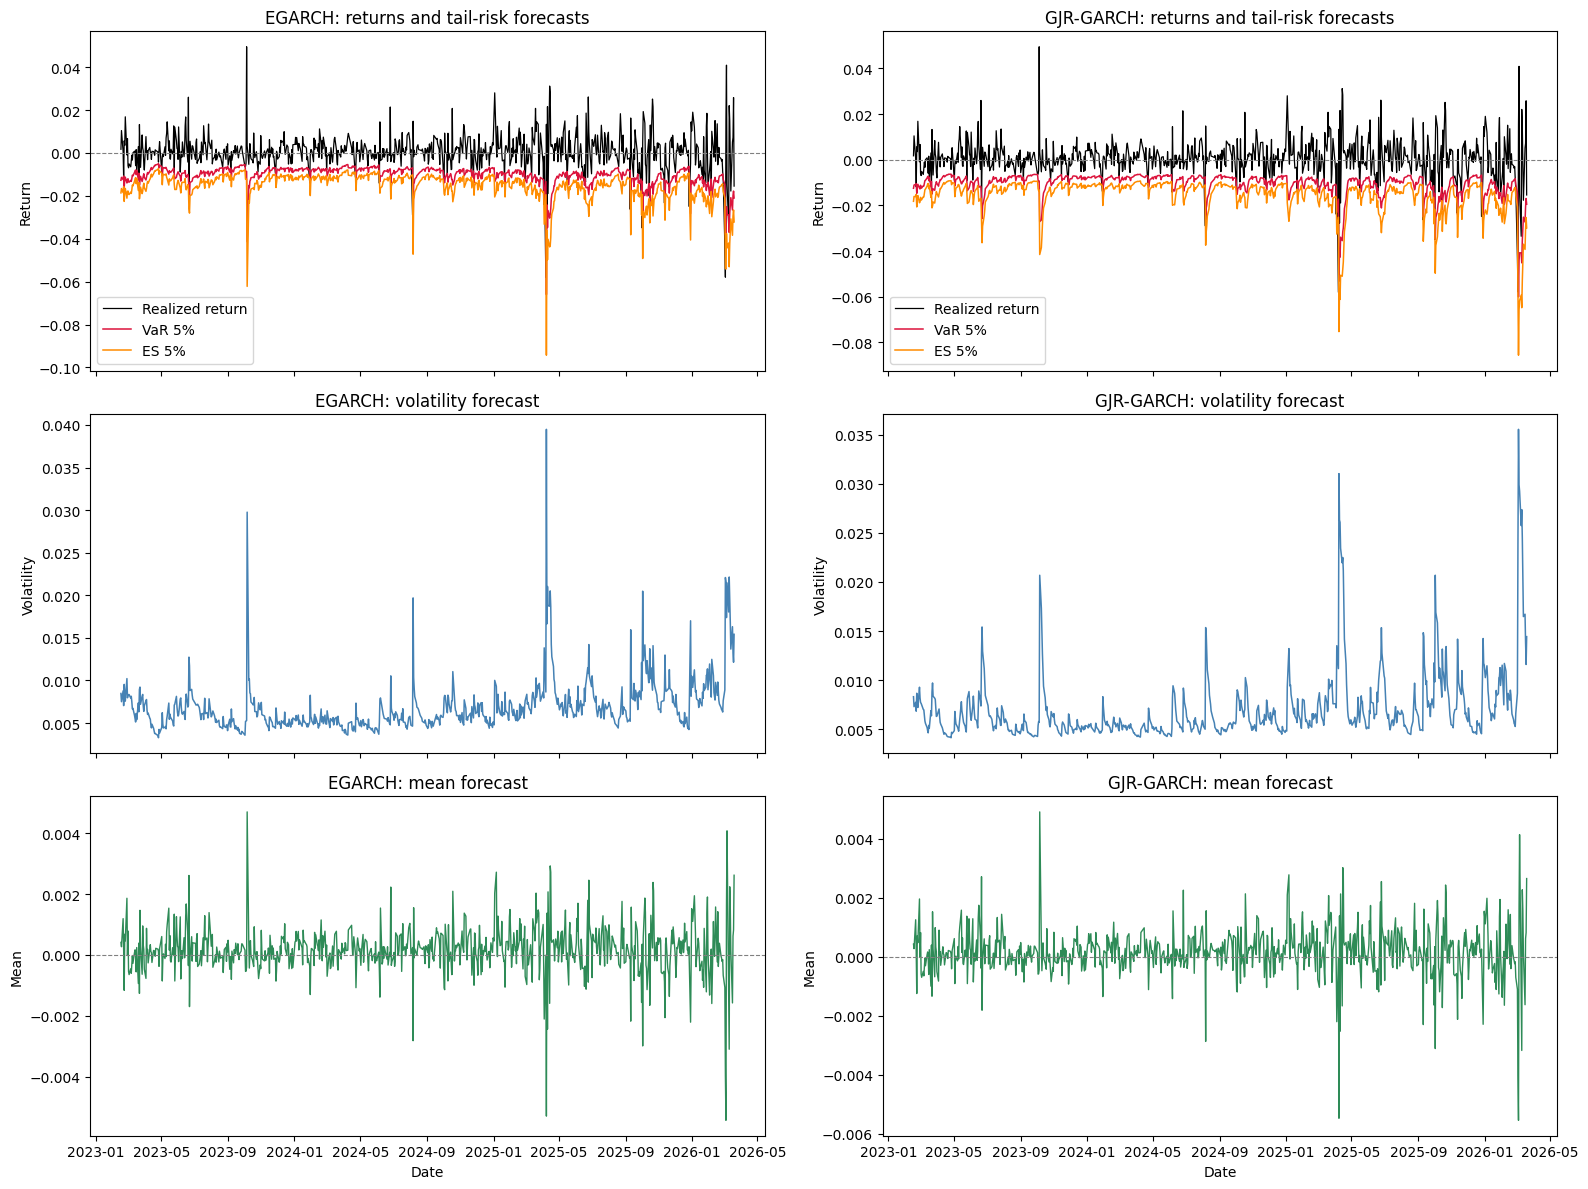

In [12]:
import matplotlib.pyplot as plt

plot_data = forecast_results.copy()
plot_data["forecast_date"] = pd.to_datetime(plot_data["forecast_date"])

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

for column_index, model_family in enumerate(["EGARCH", "GJR-GARCH"]):
    model_data = (
        plot_data[plot_data["model_family"] == model_family]
        .sort_values("forecast_date")
        .dropna(subset=["realized_return", "var_5pct", "es_5pct", "volatility_forecast", "mean_forecast"])
    )

    axes[0, column_index].plot(
        model_data["forecast_date"],
        model_data["realized_return"],
        color="black",
        linewidth=0.9,
        label="Realized return",
    )
    axes[0, column_index].plot(
        model_data["forecast_date"],
        model_data["var_5pct"],
        color="crimson",
        linewidth=1.1,
        label="VaR 5%",
    )
    axes[0, column_index].plot(
        model_data["forecast_date"],
        model_data["es_5pct"],
        color="darkorange",
        linewidth=1.1,
        label="ES 5%",
    )
    axes[0, column_index].axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
    axes[0, column_index].set_title(f"{model_family}: returns and tail-risk forecasts")
    axes[0, column_index].set_ylabel("Return")
    axes[0, column_index].legend()

    axes[1, column_index].plot(
        model_data["forecast_date"],
        model_data["volatility_forecast"],
        color="steelblue",
        linewidth=1.1,
    )
    axes[1, column_index].set_title(f"{model_family}: volatility forecast")
    axes[1, column_index].set_ylabel("Volatility")

    axes[2, column_index].plot(
        model_data["forecast_date"],
        model_data["mean_forecast"],
        color="seagreen",
        linewidth=1.0,
    )
    axes[2, column_index].axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
    axes[2, column_index].set_title(f"{model_family}: mean forecast")
    axes[2, column_index].set_ylabel("Mean")
    axes[2, column_index].set_xlabel("Date")

plt.tight_layout()
plt.show()


In [13]:
from src.analysis.risk_backtesting import backtest_forecast_results

risk_backtest_summary = backtest_forecast_results(forecast_results, alpha=0.05)
risk_backtest_summary


  model_family  n_observations  n_var_violations  violation_rate  \
0       EGARCH             764                38        0.049738   
1    GJR-GARCH             764                40        0.052356   

   expected_violation_rate  kupiec_pof_stat  kupiec_pof_p_value  \
0                     0.05         0.001104            0.973493   
1                     0.05         0.087983            0.766757   

   christoffersen_independence_stat  christoffersen_independence_p_value  \
0                          0.619667                             0.431171   
1                          0.387203                             0.533773   

   n_es_tail_observations  es_tail_calibration_stat  \
0                      38                 -1.193834   
1                      40                 -1.152642   

   es_tail_calibration_p_value  es_tail_residual_mean  
0                     0.240141              -0.001837  
1                     0.256074              -0.001554  


In [14]:
from src.analysis.economic_evaluation import (
    align_inputs,
    annualized_return_from_wealth,
    annualized_volatility,
    calmar_ratio,
    cumulative_wealth,
    drawdown_from_wealth,
    evaluate_strategy,
    max_drawdown,
    sharpe_ratio,
    simple_returns_from_log,
    sortino_ratio,
    strategy_simple_returns,
)


In [15]:
from src.analysis.economic_evaluation import (
    compute_weights_from_budget_and_var,
    positive_var,
    rolling_var_quantiles,
    weights_benchmark_econometric,
    weights_hmm_lstm_quantile_budget,
    weights_lstm,
)


## Final Economic Evaluation

The final cells keep the benchmark allocation results and simplified metrics table directly visible in the notebook.


===== Benchmark economic evaluation summary - 703 derniers jours =====
Periode : 2023-05-16 00:00:00 -> 2026-03-19 00:00:00
Nombre d'observations communes : 703


,n_observations,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,final_wealth,average_turnover,average_weight
strategy_name,,,,,,,,,,
Buy_and_hold_703_days,703,0.182711,0.138106,1.297554,1.592810,-0.189500,0.964172,1.604975,0.000000,1.000000
EGARCH_VaR_budget_fixe_703_days,703,0.167504,0.108592,1.497359,2.060667,-0.175716,0.953266,1.548148,0.054279,0.904811
GJR-GARCH_VaR_budget_fixe_703_days,703,0.152941,0.108861,1.377803,1.837089,-0.184806,0.827576,1.494519,0.045907,0.899762


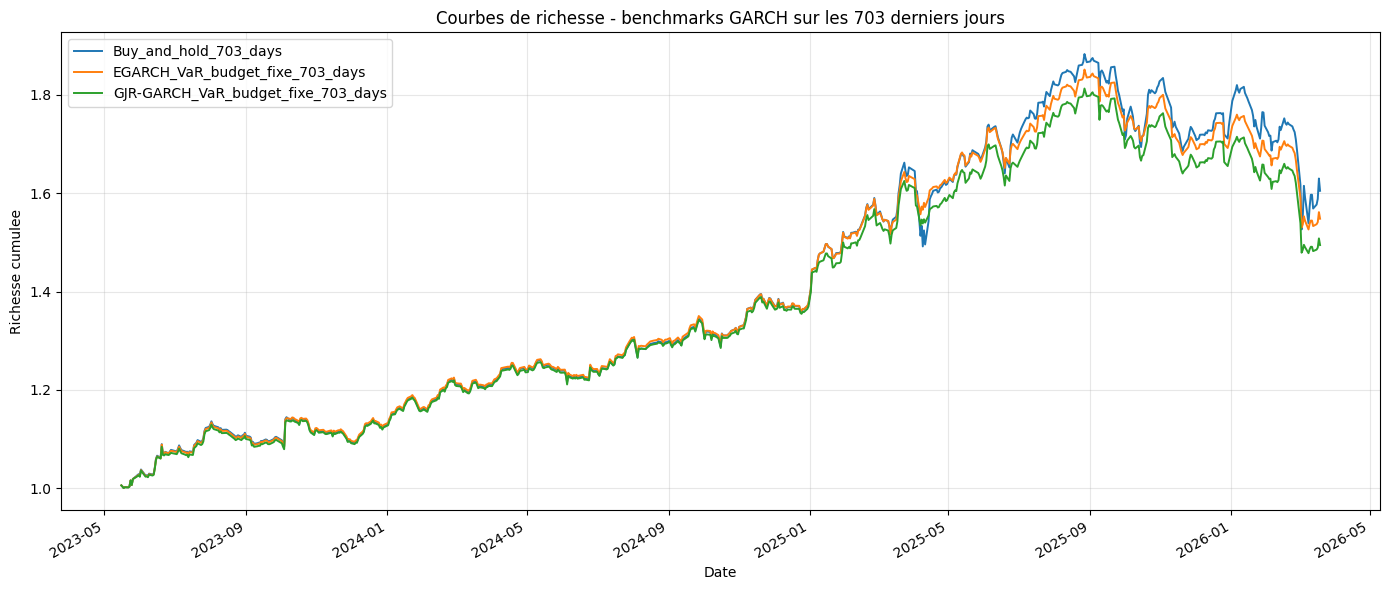

===== Derniers poids par benchmark - 703 derniers jours =====


,EGARCH,GJR-GARCH
forecast_date,,
2026-03-13,0.480034,0.397194
2026-03-16,0.376288,0.366428
2026-03-17,0.506636,0.484433
2026-03-18,0.562329,0.588634
2026-03-19,0.476278,0.512845


In [16]:
# =========================================================
# Execution de l'evaluation economique des benchmarks GARCH
# Sur les 703 derniers jours communs
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ECONOMIC_BUDGET = 0.01
TRANSACTION_COST = 0.0
WEIGHT_LAG = 1
PERIODS_PER_YEAR = 252
N_LAST_DAYS = 703

if "forecast_results" not in globals():
    raise NameError("La variable forecast_results doit etre disponible avant cette cellule.")

required_columns = ["forecast_date", "model_family", "realized_return", "var_5pct"]
missing_columns = [col for col in required_columns if col not in forecast_results.columns]
if missing_columns:
    raise KeyError(f"Colonnes manquantes dans forecast_results: {missing_columns}")

benchmark_summaries = []
benchmark_details = {}
benchmark_weights = {}

# ---------------------------------------------------------
# 1. Evaluation de chaque benchmark GARCH
# ---------------------------------------------------------

for model_family, model_data in forecast_results.groupby("model_family"):
    model_data = model_data.copy()
    model_data["forecast_date"] = pd.to_datetime(model_data["forecast_date"])
    model_data = model_data.sort_values("forecast_date").set_index("forecast_date")

    model_log_returns = pd.to_numeric(model_data["realized_return"], errors="coerce")
    model_var_forecast = pd.to_numeric(model_data["var_5pct"], errors="coerce")

    model_weights = weights_benchmark_econometric(
        var_forecast=model_var_forecast,
        B=ECONOMIC_BUDGET,
        cap=1.0,
        floor=0.0,
    )

    model_summary, model_details = evaluate_strategy(
        log_returns=model_log_returns,
        weights=model_weights,
        rf=0.0,
        transaction_cost=TRANSACTION_COST,
        weight_lag=WEIGHT_LAG,
        periods_per_year=PERIODS_PER_YEAR,
        strategy_name=f"{model_family}_VaR_budget_fixe",
    )

    benchmark_details[model_family] = model_details
    benchmark_weights[model_family] = model_weights

# ---------------------------------------------------------
# 2. Construction de l'index commun puis restriction aux 703 derniers jours
# ---------------------------------------------------------

common_index = None

for details in benchmark_details.values():
    common_index = details.index if common_index is None else common_index.intersection(details.index)

if common_index is None or common_index.empty:
    raise ValueError("Aucune date commune valide entre les benchmarks.")

common_index = common_index.sort_values()

if len(common_index) < N_LAST_DAYS:
    raise ValueError(
        f"Seulement {len(common_index)} observations communes disponibles, "
        f"impossible de prendre les {N_LAST_DAYS} derniers jours."
    )

common_index = common_index[-N_LAST_DAYS:]

# ---------------------------------------------------------
# 3. Buy and Hold aligne sur les memes 703 dates
# ---------------------------------------------------------

buy_hold_data = (
    forecast_results[["forecast_date", "realized_return"]]
    .drop_duplicates(subset=["forecast_date"])
    .copy()
)

buy_hold_data["forecast_date"] = pd.to_datetime(buy_hold_data["forecast_date"])
buy_hold_data = buy_hold_data.sort_values("forecast_date").set_index("forecast_date")

buy_hold_returns = pd.to_numeric(buy_hold_data["realized_return"], errors="coerce")
buy_hold_returns = buy_hold_returns.reindex(common_index)

buy_hold_weights = pd.Series(1.0, index=common_index, name="weight")

buy_hold_summary, buy_hold_details = evaluate_strategy(
    log_returns=buy_hold_returns,
    weights=buy_hold_weights,
    rf=0.0,
    transaction_cost=TRANSACTION_COST,
    weight_lag=0,
    periods_per_year=PERIODS_PER_YEAR,
    strategy_name="Buy_and_hold_703_days",
)

# ---------------------------------------------------------
# 4. Reevaluation des benchmarks sur les 703 memes dates
# ---------------------------------------------------------

benchmark_summaries = []
benchmark_details_703 = {}

for model_family, details in benchmark_details.items():
    details_703 = details.reindex(common_index).dropna().copy()

    wealth_703 = cumulative_wealth(details_703["strategy_simple_return"])
    drawdown_703 = drawdown_from_wealth(wealth_703)

    details_703["wealth"] = wealth_703
    details_703["drawdown"] = drawdown_703

    summary_703 = pd.Series(
        {
            "strategy_name": f"{model_family}_VaR_budget_fixe_703_days",
            "n_observations": len(details_703),
            "annualized_return": annualized_return_from_wealth(
                wealth_703,
                periods_per_year=PERIODS_PER_YEAR,
            ),
            "annualized_volatility": annualized_volatility(
                details_703["strategy_simple_return"],
                periods_per_year=PERIODS_PER_YEAR,
            ),
            "sharpe_ratio": sharpe_ratio(
                details_703["strategy_simple_return"],
                rf=0.0,
                periods_per_year=PERIODS_PER_YEAR,
            ),
            "sortino_ratio": sortino_ratio(
                details_703["strategy_simple_return"],
                rf=0.0,
                periods_per_year=PERIODS_PER_YEAR,
            ),
            "max_drawdown": max_drawdown(wealth_703),
            "calmar_ratio": calmar_ratio(
                wealth_703,
                periods_per_year=PERIODS_PER_YEAR,
            ),
            "final_wealth": wealth_703.iloc[-1] if len(wealth_703) else np.nan,
            "average_turnover": details_703["turnover"].mean() if len(details_703) else np.nan,
            "average_weight": details_703["weight_used"].mean() if len(details_703) else np.nan,
        }
    )

    benchmark_summaries.append(summary_703)
    benchmark_details_703[model_family] = details_703

# ---------------------------------------------------------
# 5. Tableau final des metriques economiques
# ---------------------------------------------------------

benchmark_economic_summary_703 = pd.DataFrame(
    [buy_hold_summary] + benchmark_summaries
).set_index("strategy_name")

print("===== Benchmark economic evaluation summary - 703 derniers jours =====")
print(f"Periode : {common_index.min()} -> {common_index.max()}")
print(f"Nombre d'observations communes : {len(common_index)}")

display(benchmark_economic_summary_703)

# ---------------------------------------------------------
# 6. Courbes de richesse
# ---------------------------------------------------------

wealth_curves_703 = pd.DataFrame({
    "Buy_and_hold_703_days": buy_hold_details["wealth"],
    **{
        f"{model_family}_VaR_budget_fixe_703_days": details["wealth"]
        for model_family, details in benchmark_details_703.items()
    },
})

ax = wealth_curves_703.plot(figsize=(14, 6), linewidth=1.4)
ax.set_title("Courbes de richesse - benchmarks GARCH sur les 703 derniers jours")
ax.set_xlabel("Date")
ax.set_ylabel("Richesse cumulee")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. Derniers poids
# ---------------------------------------------------------

benchmark_weights_df_703 = pd.DataFrame(benchmark_weights).reindex(common_index)

print("===== Derniers poids par benchmark - 703 derniers jours =====")
display(benchmark_weights_df_703.tail())


In [24]:
# =========================================================
# Tableau simplifie des metriques economiques - Benchmark GARCH
# =========================================================

economic_metrics_table = benchmark_economic_summary_703.copy()

economic_metrics_table = economic_metrics_table[
    [
        "n_observations",
        "annualized_return",
        "sharpe_ratio",
        "max_drawdown",
        "final_wealth",
    ]
]

economic_metrics_table_rounded = economic_metrics_table.copy()

economic_metrics_table_rounded["annualized_return"] = (
    economic_metrics_table_rounded["annualized_return"] * 100
)

economic_metrics_table_rounded["max_drawdown"] = (
    economic_metrics_table_rounded["max_drawdown"] * 100
)

economic_metrics_table_rounded = economic_metrics_table_rounded.rename(
    columns={
        "n_observations": "Observations",
        "annualized_return": "Rendement annualise (%)",
        "sharpe_ratio": "Sharpe ratio",
        "max_drawdown": "Max drawdown (%)",
        "final_wealth": "Richesse finale",
    }
)

economic_metrics_table_rounded = economic_metrics_table_rounded.round(4)

display(economic_metrics_table_rounded)


,Observations,Rendement annualise (%),Sharpe ratio,Max drawdown (%),Richesse finale
strategy_name,,,,,
Buy_and_hold_703_days,703,18.2711,1.2976,-18.9500,1.6050
EGARCH_VaR_budget_fixe_703_days,703,16.7504,1.4974,-17.5716,1.5481
GJR-GARCH_VaR_budget_fixe_703_days,703,15.2941,1.3778,-18.4806,1.4945
